# Rocket Algorithm — Base Implementation

Minimal Rocket sub-algorithm (Algorithm 1, Bader et al. 2025) for the fly connectome
MFAS problem. Use this as the starting point for experiments.


In [1]:
import gzip, csv, time
import numpy as np
import pandas as pd
import torch
import torch.optim as optim
from pathlib import Path

GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)
torch.manual_seed(GLOBAL_SEED)

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')
print(f"Device: {DEVICE}")

CONFIG = dict(
    DATA_FILE          = Path('../data/connectome_graph.csv.gz'),
    ROCKET_EPOCHS      = 20_000,
    ROCKET_CYCLES      = 5,
    ROCKET_LR          = 0.05,
    ROCKET_GRAD_CLIP   = 1.0,
    ROCKET_LR_DECAY_START = 0.5,
    ROCKET_LR_END_FACTOR  = 0.1,
    LOG_INTERVAL       = 100,
)


Device: mps


In [2]:
src_raw, tgt_raw, w_raw = [], [], []
with gzip.open(CONFIG['DATA_FILE'], 'rt') as f:
    reader = csv.DictReader(f)
    for row in reader:
        src_raw.append(int(row['Source Node  ID']))
        tgt_raw.append(int(row['Target Node ID']))
        w_raw.append(int(row['Edge Weight']))

src_raw = np.array(src_raw, dtype=np.int64)
tgt_raw = np.array(tgt_raw, dtype=np.int64)
w_raw   = np.array(w_raw,   dtype=np.float32)

all_nodes = np.unique(np.concatenate([src_raw, tgt_raw]))
node2idx  = {n: i for i, n in enumerate(all_nodes)}
N_VERTICES = len(all_nodes)

src_idx = np.array([node2idx[n] for n in src_raw], dtype=np.int32)
tgt_idx = np.array([node2idx[n] for n in tgt_raw], dtype=np.int32)

TOTAL_WEIGHT = float(w_raw.sum())
MAX_WEIGHT   = float(w_raw.max())
norm_w       = w_raw / MAX_WEIGHT

SRC_T = torch.tensor(src_idx, dtype=torch.long,    device=DEVICE)
TGT_T = torch.tensor(tgt_idx, dtype=torch.long,    device=DEVICE)
W_T   = torch.tensor(w_raw,   dtype=torch.float32, device=DEVICE)
NW_T  = torch.tensor(norm_w,  dtype=torch.float32, device=DEVICE)

print(f"Vertices: {N_VERTICES:,}  Edges: {len(w_raw):,}  Total weight: {TOTAL_WEIGHT:,.0f}")


Vertices: 136,648  Edges: 5,657,719  Total weight: 41,912,104


In [3]:
def score_from_positions(positions, src, tgt, weights):
    """Feedforward weight: sum of weights where position[tgt] > position[src]."""
    ff = positions[tgt] > positions[src]
    return float(weights[ff].sum())


def torch_score(positions, src_t, tgt_t, w_t):
    """Discrete feedforward score, computed on CPU for numerical stability."""
    with torch.no_grad():
        pos = positions.detach().cpu()
        s, t, w = src_t.cpu(), tgt_t.cpu(), w_t.cpu()
        ff = (pos[t] > pos[s]).float()
        return float((ff * w).sum().item())


def pct(score):
    return f"{score / TOTAL_WEIGHT * 100:.4f}%"


In [4]:
def make_beta_schedule(num_epochs, n_cycles):
    """Cyclic sigmoid sharpness schedule: beta = (cos(linspace(0, 2*pi*n_cycles, T)) + 1.1) / 2."""
    return (np.cos(np.linspace(0, 2 * n_cycles * np.pi, num_epochs)) + 1.1) / 2


def make_init_positions(n, seed=GLOBAL_SEED, device=DEVICE):
    """N(0,1) random initial positions (paper default)."""
    rng = np.random.RandomState(seed)
    return torch.tensor(rng.randn(n).astype(np.float32), device=device)


def run_rocket(src_t, tgt_t, w_t, nw_t, n_vertices, total_weight,
               num_epochs, n_cycles, lr, grad_clip,
               lr_decay_start, lr_end_factor,
               log_interval, seed,
               init_positions=None, time_limit=None):
    """Rocket sub-algorithm (Algorithm 1, Bader et al. 2025)."""
    torch.manual_seed(seed)
    np.random.seed(seed)
    device = src_t.device

    pos_data = (init_positions.clone().detach().to(torch.float32)
                if init_positions is not None else torch.randn(n_vertices, device=device))
    positions = torch.nn.Parameter(pos_data)

    optimizer = optim.Adam([positions], lr=lr)
    milestone = int(num_epochs * lr_decay_start)
    sched_const = optim.lr_scheduler.ConstantLR(optimizer, factor=1.0, total_iters=milestone)
    gamma = lr_end_factor ** (1.0 / max(num_epochs - milestone, 1))
    sched_exp = optim.lr_scheduler.ExponentialLR(optimizer, gamma=gamma)
    scheduler = optim.lr_scheduler.SequentialLR(optimizer,
                    schedulers=[sched_const, sched_exp], milestones=[milestone])

    betas = make_beta_schedule(num_epochs, n_cycles)

    with torch.no_grad():
        best_score = torch_score(positions, src_t, tgt_t, w_t)
    best_positions = positions.detach().clone()

    history = []
    start_time = time.time()

    for i in range(num_epochs):
        if time_limit and (time.time() - start_time) > time_limit:
            break

        beta = float(betas[i])

        optimizer.zero_grad()
        delta = positions[tgt_t] - positions[src_t]
        sig   = torch.sigmoid(beta * delta)
        loss  = -(sig * nw_t).sum()

        loss.backward()
        torch.nn.utils.clip_grad_norm_([positions], grad_clip)
        optimizer.step()
        scheduler.step()

        if i % log_interval == 0 or i == num_epochs - 1:
            with torch.no_grad():
                score = torch_score(positions, src_t, tgt_t, w_t)
            elapsed = time.time() - start_time

            if score > best_score:
                best_score = score
                best_positions = positions.detach().clone()

            history.append({
                'iter': i, 'score': score, 'best_score': best_score,
                'pct': score / total_weight * 100, 'best_pct': best_score / total_weight * 100,
                'beta': beta, 'elapsed': elapsed, 'lr': optimizer.param_groups[0]['lr'],
            })

    return best_positions, best_score, pd.DataFrame(history)


In [5]:
TIME_LIMIT = 120  # seconds

positions, score, hist = run_rocket(
    src_t=SRC_T, tgt_t=TGT_T, w_t=W_T, nw_t=NW_T,
    n_vertices=N_VERTICES, total_weight=TOTAL_WEIGHT,
    num_epochs=CONFIG['ROCKET_EPOCHS'],
    n_cycles=CONFIG['ROCKET_CYCLES'],
    lr=CONFIG['ROCKET_LR'],
    grad_clip=CONFIG['ROCKET_GRAD_CLIP'],
    lr_decay_start=CONFIG['ROCKET_LR_DECAY_START'],
    lr_end_factor=CONFIG['ROCKET_LR_END_FACTOR'],
    log_interval=CONFIG['LOG_INTERVAL'],
    seed=GLOBAL_SEED,
    time_limit=TIME_LIMIT,
)

print(f"Score: {score:,.0f}  ({pct(score)})  in {hist['elapsed'].max():.1f}s")


/opt/homebrew/Caskroom/miniforge/base/envs/allen/lib/python3.9/site-packages/torch/optim/lr_scheduler.py:209: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Score: 34,751,792  (82.9159%)  in 74.4s


## Seed Stability — Is the Ordering Itself Stable?

Rocket reaches a similar score (~82.5-82.9%) regardless of seed, but does it converge
to the **same vertex ordering**, or to different orderings with similar total weight?

We compare the final `positions` from several seeds:
- rank correlation (Spearman, Kendall) between orderings
- overlap of "source"/"sink" sets (first/last K vertices)
- per-vertex rank stability across seeds


In [6]:
SEED_LIST = [42, 123, 999, 7]
SEED_TIME_LIMIT = 60  # seconds per run

OUTPUT_DIR = Path('./outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

seed_positions = {}
for seed in SEED_LIST:
    pos, sc, _ = run_rocket(
        src_t=SRC_T, tgt_t=TGT_T, w_t=W_T, nw_t=NW_T,
        n_vertices=N_VERTICES, total_weight=TOTAL_WEIGHT,
        num_epochs=CONFIG['ROCKET_EPOCHS'],
        n_cycles=CONFIG['ROCKET_CYCLES'],
        lr=CONFIG['ROCKET_LR'],
        grad_clip=CONFIG['ROCKET_GRAD_CLIP'],
        lr_decay_start=CONFIG['ROCKET_LR_DECAY_START'],
        lr_end_factor=CONFIG['ROCKET_LR_END_FACTOR'],
        log_interval=CONFIG['LOG_INTERVAL'],
        seed=seed,
        time_limit=SEED_TIME_LIMIT,
    )
    seed_positions[seed] = pos.cpu().numpy()
    print(f"seed={seed}: {pct(sc)}")


/opt/homebrew/Caskroom/miniforge/base/envs/allen/lib/python3.9/site-packages/torch/optim/lr_scheduler.py:209: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


seed=42: 82.9159%


/opt/homebrew/Caskroom/miniforge/base/envs/allen/lib/python3.9/site-packages/torch/optim/lr_scheduler.py:209: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


seed=123: 82.8939%


/opt/homebrew/Caskroom/miniforge/base/envs/allen/lib/python3.9/site-packages/torch/optim/lr_scheduler.py:209: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


seed=999: 82.8786%


/opt/homebrew/Caskroom/miniforge/base/envs/allen/lib/python3.9/site-packages/torch/optim/lr_scheduler.py:209: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


seed=7: 82.8924%


In [7]:
from itertools import combinations
from scipy.stats import spearmanr, kendalltau

ranks = {seed: np.argsort(np.argsort(p)) for seed, p in seed_positions.items()}

print(f"{'seeds':<14}{'spearman':>10}{'kendall':>10}")
for s1, s2 in combinations(SEED_LIST, 2):
    rho, _ = spearmanr(seed_positions[s1], seed_positions[s2])
    tau, _ = kendalltau(seed_positions[s1], seed_positions[s2])
    print(f"{s1:>4} vs {s2:<4}  {rho:>10.4f}{tau:>10.4f}")


seeds           spearman   kendall
  42 vs 123       0.9583    0.9122
  42 vs 999       0.9585    0.9130
  42 vs 7         0.9572    0.9068
 123 vs 999       0.9596    0.9146
 123 vs 7         0.9561    0.9047
 999 vs 7         0.9585    0.9076


In [8]:
TOP_K = 1000

def edge_sets(pos, k):
    """Return (source set, sink set): the k vertices placed first / last."""
    order = np.argsort(pos)
    return set(order[:k]), set(order[-k:])

print(f"{'seeds':<14}{'source J':>10}{'sink J':>10}")
for s1, s2 in combinations(SEED_LIST, 2):
    src1, snk1 = edge_sets(seed_positions[s1], TOP_K)
    src2, snk2 = edge_sets(seed_positions[s2], TOP_K)
    j_src = len(src1 & src2) / len(src1 | src2)
    j_snk = len(snk1 & snk2) / len(snk1 | snk2)
    print(f"{s1:>4} vs {s2:<4}  {j_src:>10.4f}{j_snk:>10.4f}")


seeds           source J    sink J
  42 vs 123       0.3784    0.6461
  42 vs 999       0.3316    0.6906
  42 vs 7         0.3746    0.6878
 123 vs 999       0.3624    0.6584
 123 vs 7         0.3986    0.6420
 999 vs 7         0.3652    0.7406


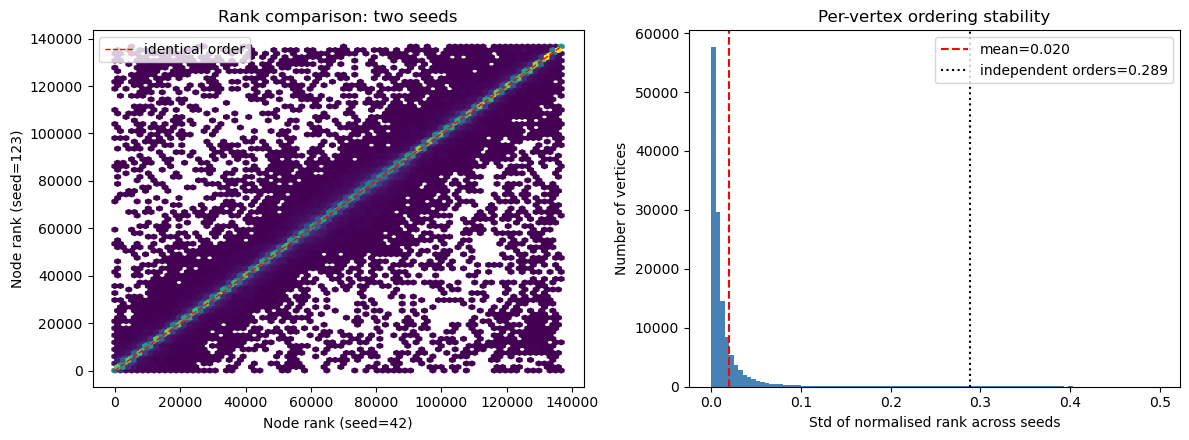

Mean rank std across seeds: 0.0195  (0 = identical order, 0.2887 = independent random orders)


In [9]:
import matplotlib.pyplot as plt

rank_frac = np.stack([ranks[s] / N_VERTICES for s in SEED_LIST])
rank_std = rank_frac.std(axis=0)
random_baseline = 1 / np.sqrt(12)  # std of Uniform(0,1): expected value for independent orderings

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

s1, s2 = SEED_LIST[0], SEED_LIST[1]
axes[0].hexbin(ranks[s1], ranks[s2], gridsize=80, cmap='viridis', mincnt=1)
axes[0].plot([0, N_VERTICES], [0, N_VERTICES], 'r--', lw=1, label='identical order')
axes[0].set_xlabel(f'Node rank (seed={s1})')
axes[0].set_ylabel(f'Node rank (seed={s2})')
axes[0].set_title('Rank comparison: two seeds')
axes[0].legend()

axes[1].hist(rank_std, bins=100, color='steelblue')
axes[1].axvline(rank_std.mean(), color='red', ls='--', label=f'mean={rank_std.mean():.3f}')
axes[1].axvline(random_baseline, color='black', ls=':', label=f'independent orders={random_baseline:.3f}')
axes[1].set_xlabel('Std of normalised rank across seeds')
axes[1].set_ylabel('Number of vertices')
axes[1].set_title('Per-vertex ordering stability')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'seed_stability.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"Mean rank std across seeds: {rank_std.mean():.4f}  "
      f"(0 = identical order, {random_baseline:.4f} = independent random orders)")
